In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [154]:
df = pd.read_csv(r'C:\Project\processed datasets\EV_usage_for_ML.csv')

In [155]:
df.head()

,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,user_income_level.1,range_anxiety_risk,effective_battery_capacity
0,2W,3.59,83.51,37.52,1.0,4.00,public_fast,1.36,5.50,7.92,clear,0.331,middle,21.54,middle,0.0,2.998
1,2W,3.44,87.33,10.61,3.0,6.00,public_slow,1.39,1.49,8.40,humid,0.285,low,20.62,low,0.0,3.004
2,2W,3.14,98.67,34.88,3.0,4.00,home,0.17,7.06,5.70,extreme_heat,0.120,low,16.03,low,0.0,3.098
3,2W,2.06,88.74,1.00,2.0,1.00,public_fast,0.55,0.12,8.29,rainy,0.331,middle,11.10,middle,0.0,1.828
4,2W,2.64,86.47,61.73,2.0,3.33,public_fast,2.67,3.19,9.28,extreme_heat,0.068,middle,13.47,middle,1.0,2.283


In [156]:
df = df.drop(columns=['user_income_level.1'])

In [157]:
df.shape

(10294, 16)

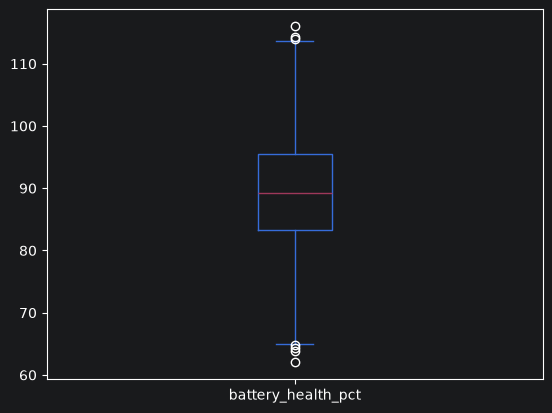

In [158]:
df['battery_health_pct'].plot(kind='box')
plt.show()

In [160]:
df.dtypes

vehicle_type                        str
battery_capacity_kwh            float64
battery_health_pct              float64
distance_km                     float64
daily_trip_count                float64
charging_frequency_per_week     float64
charging_type                       str
charging_station_distance_km    float64
energy_consumed_kwh             float64
electricity_cost_per_kwh        float64
weather_condition                   str
traffic_density                 float64
user_income_level                   str
range_km_estimated              float64
range_anxiety_risk              float64
effective_battery_capacity      float64
dtype: object

In [165]:
df.select_dtypes(include=['str']).columns

Index(['vehicle_type', 'charging_type', 'weather_condition',
       'user_income_level'],
      dtype='str')

In [159]:
oe = OrdinalEncoder()

In [169]:
cols = ['vehicle_type', 'charging_type', 'weather_condition', 'user_income_level']

df[cols] = oe.fit_transform(df[cols])

In [170]:
y = df['battery_health_pct']
X = df.drop('battery_health_pct', axis=1)

In [171]:
df = df[
    (df['battery_health_pct'] >= 0) &
    (df['battery_health_pct'] <= 100)
]

In [172]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.DataFrame'>
Index: 9126 entries, 0 to 10293
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_type                  9126 non-null   float64
 1   battery_capacity_kwh          9126 non-null   float64
 2   battery_health_pct            9126 non-null   float64
 3   distance_km                   9126 non-null   float64
 4   daily_trip_count              9126 non-null   float64
 5   charging_frequency_per_week   9126 non-null   float64
 6   charging_type                 9126 non-null   float64
 7   charging_station_distance_km  9126 non-null   float64
 8   energy_consumed_kwh           9126 non-null   float64
 9   electricity_cost_per_kwh      9126 non-null   float64
 10  weather_condition             9126 non-null   float64
 11  traffic_density               9126 non-null   float64
 12  user_income_level             9126 non-null   float64
 13  range_km_estimated

,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,effective_battery_capacity
count,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000
mean,0.700307,11.975591,87.554149,26.377405,2.513128,3.462232,1.003068,1.989680,4.347577,7.936766,1.484878,0.285646,1.176857,67.322588,0.256464,10.486014
std,0.785160,14.471102,7.086884,16.743786,0.979197,1.420551,0.814251,1.934332,2.557353,1.455246,1.095216,0.157177,0.733134,81.613692,0.435332,12.737828
min,0.000000,1.130000,62.060000,1.000000,1.000000,1.000000,0.000000,0.000000,0.110000,2.380000,0.000000,0.000000,0.000000,6.800000,0.000000,0.905000
25%,0.000000,3.000000,82.410000,15.430000,2.000000,2.000000,0.000000,0.610000,2.520000,6.940000,1.000000,0.163000,1.000000,16.840000,0.000000,2.606250
50%,0.000000,4.235000,88.255000,25.820000,2.510000,3.290000,1.000000,1.460000,4.280000,7.910000,1.000000,0.270000,1.000000,24.560000,0.000000,3.903500
75%,1.000000,8.960000,93.160000,35.320000,3.000000,4.000000,2.000000,2.680000,5.970000,8.970000,2.000000,0.387000,2.000000,51.285000,1.000000,8.035000
max,2.000000,55.910000,100.000000,187.550000,6.000000,8.000000,2.000000,17.790000,19.830000,13.090000,3.000000,0.902000,2.000000,313.120000,1.000000,51.831000


In [173]:
from sklearn.model_selection import train_test_split

X = df.drop('battery_health_pct', axis=1)
y = df['battery_health_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [174]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

In [175]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("MAE:", mean_absolute_error(y_test, pred))
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2 Score:", r2_score(y_test, pred))

### Linear regression

In [177]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
lr = LinearRegression()

evaluate_model(
    lr,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

MAE: 3.613701452952918
MSE: 20.861260237283133
R2 Score: 0.5717116525370407


### Ridge

In [179]:
ridge = Ridge(alpha=1.0)

evaluate_model(
    ridge,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

MAE: 3.612492855471601
MSE: 20.894377501968794
R2 Score: 0.571031744496808


## Lasso

In [180]:
lasso = Lasso(alpha=0.1)

evaluate_model(
    lasso,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

MAE: 4.000933613796216
MSE: 25.347318148854377
R2 Score: 0.4796114482485099


### Elastic net

In [181]:
elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

evaluate_model(
    elastic,
    X_train_scaled, X_test_scaled,
    y_train, y_test
)

MAE: 4.297593705495878
MSE: 28.66092339731019
R2 Score: 0.4115820722729694


### Decision Tree regressor

In [187]:
dtr = DecisionTreeRegressor(
    random_state=42
)

evaluate_model(
    dtr,
    X_train, X_test,
    y_train, y_test
)

MAE: 3.3251204819277107
MSE: 21.078788335158823
R2 Score: 0.567245731087126


### Random Forest

In [186]:
rfr = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

evaluate_model(
    rfr,
    X_train, X_test,
    y_train, y_test
)

MAE: 2.3365546367287355
MSE: 10.531723192973736
R2 Score: 0.7837803531066309


In [188]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

evaluate_model(
    xgb,
    X_train, X_test,
    y_train, y_test
)

MAE: 2.5234350746380407
MSE: 11.262519218564345
R2 Score: 0.7687768768749637


In [189]:
results = []

models = {
    "Linear Regression": (lr, X_train_scaled, X_test_scaled),
    "Ridge": (ridge, X_train_scaled, X_test_scaled),
    "Lasso": (lasso, X_train_scaled, X_test_scaled),
    "Elastic Net": (elastic, X_train_scaled, X_test_scaled),
    "Decision Tree": (dtr, X_train, X_test),
    "Random Forest": (rfr, X_train, X_test),
    "XGBoost": (xgb, X_train, X_test)
}

for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

               Model       MAE        MSE        R2
5      Random Forest  2.336555  10.531723  0.783780
6            XGBoost  2.523435  11.262519  0.768777
0  Linear Regression  3.613701  20.861260  0.571712
1              Ridge  3.612493  20.894378  0.571032
4      Decision Tree  3.325120  21.078788  0.567246
2              Lasso  4.000934  25.347318  0.479611
3        Elastic Net  4.297594  28.660923  0.411582


In [190]:
rf_train_pred = rfr.predict(X_train)

print("Random Forest Train R2:",
      r2_score(y_train, rf_train_pred))

print("Random Forest Test R2:",
      r2_score(y_test, rfr_pred))

Random Forest Train R2: 0.9728026070876183
Random Forest Test R2: -0.006586230124025594


In [191]:
xgb_train_pred = xgb.predict(X_train)

print("XGBoost Train R2:",
      r2_score(y_train, xgb_train_pred))

print("XGBoost Test R2:",
      r2_score(y_test, xgb_pred))

XGBoost Train R2: 0.8384000064216999
XGBoost Test R2: -0.0112281637964331


In [192]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rfr = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

# Train
rfr.fit(X_train, y_train)

# Predictions
rf_train_pred = rfr.predict(X_train)
rf_test_pred = rfr.predict(X_test)

# Evaluation
print("TRAIN")
print("MAE:", mean_absolute_error(y_train, rf_train_pred))
print("MSE:", mean_squared_error(y_train, rf_train_pred))
print("R2:", r2_score(y_train, rf_train_pred))

print("\nTEST")
print("MAE:", mean_absolute_error(y_test, rf_test_pred))
print("MSE:", mean_squared_error(y_test, rf_test_pred))
print("R2:", r2_score(y_test, rf_test_pred))

TRAIN
MAE: 3.734474289706569
MSE: 21.068273148121463
R2: 0.5834280361893345

TEST
MAE: 4.008937909573631
MSE: 24.777006977692338
R2: 0.49132011906984974


In [194]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rfr,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 scores: [0.52087697 0.52965831 0.51279649 0.49627619 0.50706913]
Mean CV R2: 0.5133354183469259


### Tunned RandomForest

In [195]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 1.0]
}

rf = RandomForestRegressor(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV R2:")
print(random_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': None}

Best CV R2:
0.7572264604208261


In [196]:
best_rf = random_search.best_estimator_

In [197]:
best_rf_pred = best_rf.predict(X_test)

print("Test MAE:",
      mean_absolute_error(y_test, best_rf_pred))

print("Test MSE:",
      mean_squared_error(y_test, best_rf_pred))

print("Test R2:",
      r2_score(y_test, best_rf_pred))

Test MAE: 2.430892293780956
Test MSE: 11.371123473591899
Test R2: 0.7665471967701123


In [198]:
best_rf_train_pred = best_rf.predict(X_train)

print("Train R2:",
      r2_score(y_train, best_rf_train_pred))

print("Test R2:",
      r2_score(y_test, best_rf_pred))

Train R2: 0.9124671696949427
Test R2: 0.7665471967701123


In [199]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': None}


In [200]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

charging_frequency_per_week     0.259083
effective_battery_capacity      0.208472
electricity_cost_per_kwh        0.207865
battery_capacity_kwh            0.182604
range_km_estimated              0.042589
charging_station_distance_km    0.021485
range_anxiety_risk              0.019203
traffic_density                 0.015190
distance_km                     0.014024
energy_consumed_kwh             0.012385
weather_condition               0.005051
daily_trip_count                0.004440
charging_type                   0.004121
user_income_level               0.003093
vehicle_type                    0.000396
dtype: float64


In [201]:
cv_scores_tuned = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Tuned RF CV scores:", cv_scores_tuned)
print("Mean Tuned RF CV R2:", cv_scores_tuned.mean())

Tuned RF CV scores: [0.77185115 0.76261142 0.75928282 0.74511999 0.74726691]
Mean Tuned RF CV R2: 0.7572264604208261


In [202]:
df[['battery_health_pct', 'range_anxiety_risk']].corr()

,battery_health_pct,range_anxiety_risk
battery_health_pct,1.000000,-0.302198
range_anxiety_risk,-0.302198,1.000000


In [203]:
df[['battery_health_pct', 'range_anxiety_risk']].head(20)

,battery_health_pct,range_anxiety_risk
0,83.51,0.0
1,87.33,0.0
2,98.67,0.0
3,88.74,0.0
4,86.47,1.0
5,89.19,0.0
6,92.69,0.0
7,76.14,0.0
11,89.03,0.0
12,93.80,0.0


In [204]:
df.groupby('range_anxiety_risk')['battery_health_pct'].agg(
    ['count', 'mean', 'min', 'max']
)

,count,mean,min,max
range_anxiety_risk,,,,
0.00,6728,88.816764,67.03,99.99
0.19,71,87.773099,69.35,99.84
1.00,2327,83.896897,62.06,100.00


In [205]:
df.corr(numeric_only=True)['range_anxiety_risk'].sort_values(ascending=False)

range_anxiety_risk              1.000000
charging_frequency_per_week     0.405977
charging_station_distance_km    0.358932
electricity_cost_per_kwh        0.224761
energy_consumed_kwh             0.171417
distance_km                     0.160264
traffic_density                 0.020670
daily_trip_count               -0.002488
user_income_level              -0.005540
charging_type                  -0.010243
weather_condition              -0.010291
range_km_estimated             -0.228942
battery_capacity_kwh           -0.229685
effective_battery_capacity     -0.243562
vehicle_type                   -0.263091
battery_health_pct             -0.302198
Name: range_anxiety_risk, dtype: float64

### Tunned XGBoost

In [206]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [207]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also

In [208]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV R2:")
print(xgb_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best CV R2:
0.9559092136594408


In [209]:
best_xgb = xgb_search.best_estimator_

In [210]:
best_xgb_pred = best_xgb.predict(X_test)

print("Test MAE:",
      mean_absolute_error(y_test, best_xgb_pred))

print("Test MSE:",
      mean_squared_error(y_test, best_xgb_pred))

print("Test R2:",
      r2_score(y_test, best_xgb_pred))

Test MAE: 0.9733635164325626
Test MSE: 2.0438402783586267
Test R2: 0.9580393051359368


In [211]:
xgb_train_pred = best_xgb.predict(X_train)

print("Train R2:",
      r2_score(y_train, xgb_train_pred))

print("Test R2:",
      r2_score(y_test, best_xgb_pred))

Train R2: 0.995882622595552
Test R2: 0.9580393051359368


In [212]:
xgb_cv_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("XGBoost CV scores:", xgb_cv_scores)
print("Mean XGBoost CV R2:", xgb_cv_scores.mean())

XGBoost CV scores: [0.96087362 0.96231567 0.95482715 0.95334046 0.95052584]
Mean XGBoost CV R2: 0.9563765481388634


In [213]:
importance_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance_xgb)

charging_frequency_per_week     0.322343
range_anxiety_risk              0.137457
electricity_cost_per_kwh        0.120727
vehicle_type                    0.097542
battery_capacity_kwh            0.094960
effective_battery_capacity      0.092761
range_km_estimated              0.053661
weather_condition               0.018902
charging_station_distance_km    0.013746
daily_trip_count                0.010313
distance_km                     0.008930
energy_consumed_kwh             0.007821
traffic_density                 0.007344
user_income_level               0.006914
charging_type                   0.006579
dtype: float32


In [214]:
print("RANDOM FOREST")
print("CV R2:", cv_scores_tuned.mean())
print("Test R2:", r2_score(y_test, best_rf_pred))
print("Test MAE:", mean_absolute_error(y_test, best_rf_pred))
print("Test MSE:", mean_squared_error(y_test, best_rf_pred))

print("\nXGBOOST")
print("CV R2:", xgb_cv_scores.mean())
print("Test R2:", r2_score(y_test, best_xgb_pred))
print("Test MAE:", mean_absolute_error(y_test, best_xgb_pred))
print("Test MSE:", mean_squared_error(y_test, best_xgb_pred))

RANDOM FOREST
CV R2: 0.7572264604208261
Test R2: 0.7665471967701123
Test MAE: 2.430892293780956
Test MSE: 11.371123473591899

XGBOOST
CV R2: 0.9563765481388634
Test R2: 0.9580393051359368
Test MAE: 0.9733635164325626
Test MSE: 2.0438402783586267


In [215]:
X_train.columns

Index(['vehicle_type', 'battery_capacity_kwh', 'distance_km',
       'daily_trip_count', 'charging_frequency_per_week', 'charging_type',
       'charging_station_distance_km', 'energy_consumed_kwh',
       'electricity_cost_per_kwh', 'weather_condition', 'traffic_density',
       'user_income_level', 'range_km_estimated', 'range_anxiety_risk',
       'effective_battery_capacity'],
      dtype='str')

In [217]:
fh = open(r'C:\Project\EV station website\pickle files\battery_health.pkl','wb')
pickle.dump(xgb_search, fh)
fh.close()